In [1]:
#Set-up
import numpy as np
import matplotlib.pyplot as plt

# Personalized parameters
D = 5
S = 92

# Dataset: (x1, x2, y)
data = [
    (D - 1, S + 1, 0),
    (D + 3, S - 2, 0),
    (D - 5, S + 3, 1),
    (D + 2, S - 4, 1),
]

print(f"D = {D}, S = {S}\n")
for x1, x2, y in data:
    print(f"(x1={x1}, x2={x2}; y={y})")


D = 5, S = 92

(x1=4, x2=93; y=0)
(x1=8, x2=90; y=0)
(x1=0, x2=95; y=1)
(x1=7, x2=88; y=1)


In [2]:
#Task 1 - Probabilities
def log_odds(x1, x2, D):
    return x1 - x2 - D

def sigmoid(g):
    return 1 / (1 + np.exp(-g))

results = []
for x1, x2, y in data:
    g = log_odds(x1, x2, D)
    p = sigmoid(g)
    results.append((x1, x2, y, g, p))
    print(f"(x1={x1}, x2={x2}, y={y}) -> g(x) = {g}, sigma(g(x)) = {p:.6e}")


(x1=4, x2=93, y=0) -> g(x) = -94, sigma(g(x)) = 1.500786e-41
(x1=8, x2=90, y=0) -> g(x) = -87, sigma(g(x)) = 1.645811e-38
(x1=0, x2=95, y=1) -> g(x) = -100, sigma(g(x)) = 3.720076e-44
(x1=7, x2=88, y=1) -> g(x) = -86, sigma(g(x)) = 4.473779e-38


In [3]:
# Task 2 - predicted labels
final_results = []
for x1, x2, y, g, p in results:
    y_hat = 1 if p >= 0.5 else 0
    final_results.append((x1, x2, y, g, p, y_hat))
    print(f"(x1={x1}, x2={x2}) -> p={p:.6e}, true y={y}, predicted y_hat={y_hat}")


(x1=4, x2=93) -> p=1.500786e-41, true y=0, predicted y_hat=0
(x1=8, x2=90) -> p=1.645811e-38, true y=0, predicted y_hat=0
(x1=0, x2=95) -> p=3.720076e-44, true y=1, predicted y_hat=0
(x1=7, x2=88) -> p=4.473779e-38, true y=1, predicted y_hat=0


In [4]:
# Task 3 -log loss
eps = 1e-15  # to avoid log(0)
n = len(final_results)
total = 0

for x1, x2, y, g, p, y_hat in final_results:
    p_clipped = np.clip(p, eps, 1 - eps)
    term = y * np.log(p_clipped) + (1 - y) * np.log(1 - p_clipped)
    total += term
    print(f"(x1={x1}, x2={x2}, y={y}): term = {term:.6f}")

log_loss = -total / n
print(f"\nLog-Loss for the dataset = {log_loss:.6f}")

(x1=4, x2=93, y=0): term = -0.000000
(x1=8, x2=90, y=0): term = -0.000000
(x1=0, x2=95, y=1): term = -34.538776
(x1=7, x2=88, y=1): term = -34.538776

Log-Loss for the dataset = 17.269388


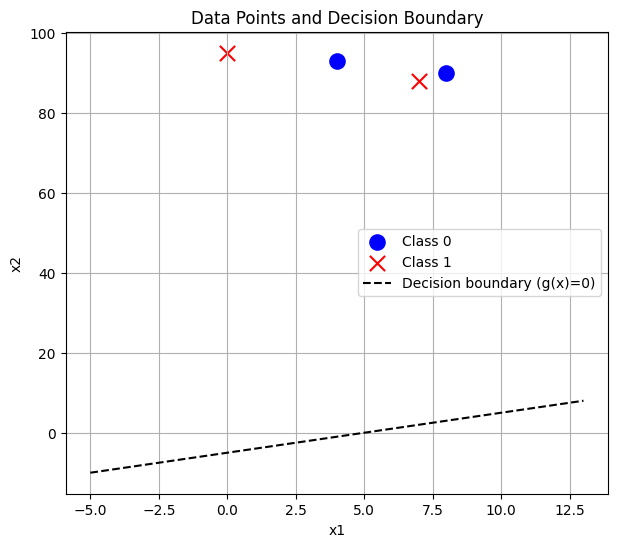

In [5]:
# plot
x1_vals = [r[0] for r in final_results]
x2_vals = [r[1] for r in final_results]
y_vals = [r[2] for r in final_results]

plt.figure(figsize=(7, 6))

for x1, x2, y in zip(x1_vals, x2_vals, y_vals):
    color = 'blue' if y == 0 else 'red'
    marker = 'o' if y == 0 else 'x'
    plt.scatter(x1, x2, c=color, marker=marker, s=120,
                label=f'Class {y}' if f'Class {y}' not in plt.gca().get_legend_handles_labels()[1] else "")

x1_line = np.linspace(min(x1_vals) - 5, max(x1_vals) + 5, 100)
x2_line = x1_line - D
plt.plot(x1_line, x2_line, 'k--', label='Decision boundary (g(x)=0)')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Data Points and Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()